# R3D-18 3D CNN Study

Systematic comparison of R3D-18 configurations for per-rep push-up form classification.

**Data source:** Manually annotated reps with human-labeled frame boundaries (no state machine).

**Study design:**
1. **Experiment A**: Full-frame input (frozen backbone)
2. **Experiment B**: YOLO-crop input (frozen backbone)
3. **Winner**: Unfreeze backbone layers (1 block, 2 blocks)
4. **Hyperparameter tuning**: LR + batch size sweep on best config
5. **Final comparison** table + plots

All experiments use 5-fold stratified CV split by video to prevent data leakage.

## Setup + Data Loading

In [1]:
import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from model import PushUpR3D
from datasets import (
    PushUpRepVideoDataset, PushUpRepCroppedVideoDataset,
    PrecomputedDataset, precompute_tensors, preload_videos,
)
from training import run_rep_kfold_cv
from data_loader import load_annotations, extract_keypoints, attach_keypoints

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

# # ============================================================
# # CONFIGURATION — adjust these paths for your environment
# # ============================================================
# ONEDRIVE_DIR = Path.home() / "Library/CloudStorage/OneDrive-SingaporeManagementUniversity"
# DATASET_DIR  = ONEDRIVE_DIR / "Group 4 Deep Learning for Computer Vision Project - training_dataset"

# ANNOTATIONS   = DATASET_DIR / "annotations_template.xlsx"  # CSV or XLSX
# VIDEO_DIR     = DATASET_DIR / "videos"                      # all .mp4 files here
# KEYPOINT_DIR  = Path("keypoints")                           # YOLO keypoints saved locally
# OUTPUT_DIR    = Path("outputs")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# CONFIGURATION — Vast.ai paths
# ============================================================
ANNOTATIONS   = Path("annotations_template.xlsx")
VIDEO_DIR     = Path("videos")
KEYPOINT_DIR  = Path("keypoints")
OUTPUT_DIR    = Path("outputs")
PRECOMP_DIR   = Path("precomputed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda"

# CV settings
RANDOM_STATE = 42
N_SPLITS     = 5
N_FRAMES     = 16   # frames sampled per rep

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")
print(f"Video dir: {VIDEO_DIR}")
print(f"Annotations: {ANNOTATIONS}")

Device: cuda
Video dir: videos
Annotations: annotations_template.xlsx


In [4]:
# Load manually annotated rep boundaries (supports CSV and XLSX)
rep_segments = load_annotations(ANNOTATIONS, VIDEO_DIR)

n_good = sum(1 for r in rep_segments if r["label"] == 0)
n_bad  = sum(1 for r in rep_segments if r["label"] == 1)
unique_videos = set(r["video_id"] for r in rep_segments)

print(f"Total reps: {len(rep_segments)} (good={n_good}, bad={n_bad})")
print(f"Unique videos: {len(unique_videos)}")
print(f"Mean reps/video: {len(rep_segments)/max(len(unique_videos),1):.1f}")

# Rep length distribution
if rep_segments:
    rep_lengths = [r["end_frame"] - r["start_frame"] for r in rep_segments]
    print(f"Rep length (frames): min={min(rep_lengths)}, max={max(rep_lengths)}, "
          f"median={np.median(rep_lengths):.0f}")

INFO: Loaded 357 reps from annotations_template.xlsx (skipped 6)


Total reps: 357 (good=165, bad=192)
Unique videos: 238
Mean reps/video: 1.5
Rep length (frames): min=11, max=396, median=63


## Extract YOLO Keypoints (one-time)

Runs YOLO pose estimation on all videos and saves keypoints as `.npy` files.
Skips videos that already have keypoints extracted. Only needed for Experiment B (YOLO-crop).

In [5]:
# Extract keypoints (skips already-extracted videos)
extract_keypoints(rep_segments, KEYPOINT_DIR)

# Attach keypoints to rep dicts for the cropped dataset
attach_keypoints(rep_segments, KEYPOINT_DIR)

# Verify
has_kps = sum(1 for r in rep_segments if "keypoints" in r)
print(f"Reps with keypoints: {has_kps}/{len(rep_segments)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


INFO: Keypoints already exist: 1.npy
INFO: Keypoints already exist: 10.npy
INFO: Keypoints already exist: 11.npy
INFO: Keypoints already exist: 12.npy
INFO: Keypoints already exist: 13.npy
INFO: Keypoints already exist: 14.npy
INFO: Keypoints already exist: 15.npy
INFO: Keypoints already exist: 16.npy
INFO: Keypoints already exist: 17.npy
INFO: Keypoints already exist: 18.npy
INFO: Keypoints already exist: 19.npy
INFO: Keypoints already exist: 2.npy
INFO: Keypoints already exist: 20.npy
INFO: Extracting keypoints: 20260227_084626000_iOS
INFO:   Saved: 20260227_084626000_iOS.npy (120 frames)
INFO: Extracting keypoints: 20260227_084636000_iOS
INFO:   Saved: 20260227_084636000_iOS.npy (167 frames)
INFO: Extracting keypoints: 20260227_084906000_iOS
INFO:   Saved: 20260227_084906000_iOS.npy (166 frames)
INFO: Extracting keypoints: 20260227_084918000_iOS
INFO:   Saved: 20260227_084918000_iOS.npy (145 frames)
INFO: Extracting keypoints: 20260227_084926000_iOS
INFO:   Saved: 20260227_084926000

Reps with keypoints: 357/357


In [6]:
# Pre-extract all rep frames to disk (one-time cost, survives kernel restarts)
# Saves preprocessed 112x112 RGB frames as .npy files — no more video decoding during training

t0 = time.time()

# Full-frame version (for Experiment A)
print("Precomputing full-frame tensors...")
precompute_tensors(rep_segments, PRECOMP_DIR / "full", n_frames=N_FRAMES, mode="full")

# YOLO-crop version (for Experiment B)
reps_with_kps = [r for r in rep_segments if "keypoints" in r]
print("Precomputing YOLO-crop tensors...")
precompute_tensors(reps_with_kps, PRECOMP_DIR / "crop", n_frames=N_FRAMES, mode="crop")

print(f"\nPrecompute done in {time.time() - t0:.0f}s")
print(f"Full-frame reps: {len(list((PRECOMP_DIR / 'full').glob('*.npy')))}")
print(f"YOLO-crop reps:  {len(list((PRECOMP_DIR / 'crop').glob('*.npy')))}")
print("These files persist on disk — no need to redo on kernel restart.")

Precomputing full-frame tensors...


INFO:   Precomputed 50/357 reps...
INFO:   Precomputed 100/357 reps...
INFO:   Precomputed 150/357 reps...
INFO:   Precomputed 200/357 reps...
INFO:   Precomputed 250/357 reps...
INFO:   Precomputed 300/357 reps...
INFO:   Precomputed 350/357 reps...
INFO: Precompute done: 357 saved, 0 skipped (already existed) in precomputed/full


Precomputing YOLO-crop tensors...


INFO:   Precomputed 50/357 reps...
INFO:   Precomputed 100/357 reps...
INFO:   Precomputed 150/357 reps...
INFO:   Precomputed 200/357 reps...
INFO:   Precomputed 250/357 reps...
INFO:   Precomputed 300/357 reps...
INFO:   Precomputed 350/357 reps...
INFO: Precompute done: 357 saved, 0 skipped (already existed) in precomputed/crop



Precompute done in 1368s
Full-frame reps: 357
YOLO-crop reps:  357
These files persist on disk — no need to redo on kernel restart.


---
## Experiment A: Full-Frame R3D-18 (Frozen Backbone)

Standard preprocessing: resize to 128x171, center crop to 112x112.
Only the FC head is trainable (1,026 params).

In [7]:
def make_model_frozen():
    return PushUpR3D(freeze_backbone=True)

def make_full_frame_dataset(reps):
    return PrecomputedDataset(reps, PRECOMP_DIR / "full", augment=False)

def make_full_frame_dataset_aug(reps):
    return PrecomputedDataset(reps, PRECOMP_DIR / "full", augment=True)

print(f"Experiment A: Full-frame, frozen backbone (precomputed)")
print(f"  Trainable params: {make_model_frozen().trainable_param_count():,}")
print(f"  Augmentation: horizontal flip, color jitter")

t0 = time.time()
results_A = run_rep_kfold_cv(
    model_factory=make_model_frozen,
    dataset_factory=make_full_frame_dataset,
    rep_segments=rep_segments,
    n_splits=N_SPLITS,
    n_epochs=30,
    batch_size=8,
    lr=1e-3,
    patience=10,
    device_str=DEVICE,
    random_state=RANDOM_STATE,
    train_dataset_factory=make_full_frame_dataset_aug,
)
time_A = time.time() - t0

accs_A = [f["val_accuracy"] for f in results_A["fold_results"]]
print(f"\nExperiment A results:")
print(f"  Per-fold: {[f'{a:.1%}' for a in accs_A]}")
print(f"  Mean: {np.mean(accs_A):.1%} +/- {np.std(accs_A):.1%}")
print(f"  Time: {time_A:.0f}s")

Experiment A: Full-frame, frozen backbone (precomputed)
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:01<00:00, 107MB/s]  
INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)


  Trainable params: 1,026
  Augmentation: horizontal flip, color jitter
  Fold 0 | Epoch 01/30 | train_loss=0.7089 | val_loss=0.6770 | val_acc=53.6% *
  Fold 0 | Epoch 02/30 | train_loss=0.6329 | val_loss=0.5853 | val_acc=72.5% *
  Fold 0 | Epoch 03/30 | train_loss=0.5935 | val_loss=0.5826 | val_acc=71.0%
  Fold 0 | Epoch 04/30 | train_loss=0.5562 | val_loss=0.6480 | val_acc=63.8%
  Fold 0 | Epoch 05/30 | train_loss=0.5398 | val_loss=0.5516 | val_acc=68.1%
  Fold 0 | Epoch 06/30 | train_loss=0.5328 | val_loss=0.5537 | val_acc=71.0%
  Fold 0 | Epoch 07/30 | train_loss=0.5071 | val_loss=0.5577 | val_acc=68.1%
  Fold 0 | Epoch 08/30 | train_loss=0.4534 | val_loss=0.5596 | val_acc=69.6%
  Fold 0 | Epoch 09/30 | train_loss=0.4699 | val_loss=0.5939 | val_acc=68.1%
  Fold 0 | Epoch 10/30 | train_loss=0.4709 | val_loss=0.5924 | val_acc=72.5%
  Fold 0 | Epoch 11/30 | train_loss=0.4450 | val_loss=0.5800 | val_acc=72.5%


INFO: Fold 0: early stopping at epoch 11 (best_acc=0.7246)


  Fold 0 | Epoch 12/30 | train_loss=0.4502 | val_loss=0.6217 | val_acc=68.1%


...

  Fold 4 | Epoch 01/30 | train_loss=0.7438 | val_loss=0.6513 | val_acc=56.0% *
  Fold 4 | Epoch 02/30 | train_loss=0.6416 | val_loss=0.6466 | val_acc=61.3% *
  Fold 4 | Epoch 03/30 | train_loss=0.5949 | val_loss=0.5953 | val_acc=61.3%
  Fold 4 | Epoch 04/30 | train_loss=0.5531 | val_loss=0.6216 | val_acc=58.7%
  Fold 4 | Epoch 05/30 | train_loss=0.5438 | val_loss=0.6385 | val_acc=61.3%
  Fold 4 | Epoch 06/30 | train_loss=0.5264 | val_loss=0.6587 | val_acc=64.0% *
  Fold 4 | Epoch 07/30 | train_loss=0.5168 | val_loss=0.5975 | val_acc=60.0%
  Fold 4 | Epoch 08/30 | train_loss=0.5036 | val_loss=0.5943 | val_acc=62.7%
  Fold 4 | Epoch 09/30 | train_loss=0.4758 | val_loss=0.5855 | val_acc=64.0%
  Fold 4 | Epoch 10/30 | train_loss=0.4672 | val_loss=0.5852 | val_acc=65.3% *
  Fold 4 | Epoch 11/30 | train_loss=0.4937 | val_loss=0.6757 | val_acc=69.3% *
  Fold 4 | Epoch 12/30 | train_loss=0.5187 | val_loss=0.5762 | val_acc=68.0%
  Fold 4 | Epoch 13/30 | train_loss=0.4466 | val_loss=0.5848 | val

INFO: Fold 4: early stopping at epoch 20 (best_acc=0.6933)


  Fold 4 | Epoch 21/30 | train_loss=0.4317 | val_loss=0.6095 | val_acc=64.0%


INFO: Fold 4: val_accuracy=0.6933



Experiment A results:
  Per-fold: ['72.5%', '80.0%', '80.9%', '73.3%', '69.3%']
  Mean: 75.2% +/- 4.5%
  Time: 472s


---
## Experiment B: YOLO-Crop R3D-18 (Frozen Backbone)

Uses YOLO keypoints to compute per-frame bounding box, crops to the person,
resizes crop to 112x112. Same frozen backbone, only FC trainable.

In [8]:
# reps_with_kps already defined in precompute cell
print(f"Reps with keypoints for YOLO-crop: {len(reps_with_kps)}/{len(rep_segments)}")

def make_cropped_dataset(reps):
    return PrecomputedDataset(reps, PRECOMP_DIR / "crop", augment=False)

def make_cropped_dataset_aug(reps):
    return PrecomputedDataset(reps, PRECOMP_DIR / "crop", augment=True)

print(f"\nExperiment B: YOLO-crop, frozen backbone (precomputed)")
print(f"  Trainable params: {make_model_frozen().trainable_param_count():,}")

t0 = time.time()
results_B = run_rep_kfold_cv(
    model_factory=make_model_frozen,
    dataset_factory=make_cropped_dataset,
    rep_segments=reps_with_kps,
    n_splits=N_SPLITS,
    n_epochs=30,
    batch_size=8,
    lr=1e-3,
    patience=10,
    device_str=DEVICE,
    random_state=RANDOM_STATE,
    train_dataset_factory=make_cropped_dataset_aug,
)
time_B = time.time() - t0

accs_B = [f["val_accuracy"] for f in results_B["fold_results"]]
print(f"\nExperiment B results:")
print(f"  Per-fold: {[f'{a:.1%}' for a in accs_B]}")
print(f"  Mean: {np.mean(accs_B):.1%} +/- {np.std(accs_B):.1%}")
print(f"  Time: {time_B:.0f}s")

Reps with keypoints for YOLO-crop: 357/357

Experiment B: YOLO-crop, frozen backbone (precomputed)


INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)


  Trainable params: 1,026
  Fold 0 | Epoch 01/30 | train_loss=0.7346 | val_loss=0.6672 | val_acc=59.4% *
  Fold 0 | Epoch 02/30 | train_loss=0.6405 | val_loss=0.6456 | val_acc=50.7%
  Fold 0 | Epoch 03/30 | train_loss=0.5915 | val_loss=0.6114 | val_acc=58.0%
  Fold 0 | Epoch 04/30 | train_loss=0.5627 | val_loss=0.6021 | val_acc=68.1% *
  Fold 0 | Epoch 05/30 | train_loss=0.5391 | val_loss=0.6068 | val_acc=63.8%
  Fold 0 | Epoch 06/30 | train_loss=0.5314 | val_loss=0.6360 | val_acc=66.7%
  Fold 0 | Epoch 07/30 | train_loss=0.4925 | val_loss=0.5780 | val_acc=63.8%
  Fold 0 | Epoch 08/30 | train_loss=0.4859 | val_loss=0.5721 | val_acc=66.7%
  Fold 0 | Epoch 09/30 | train_loss=0.4627 | val_loss=0.6238 | val_acc=63.8%
  Fold 0 | Epoch 10/30 | train_loss=0.4621 | val_loss=0.5830 | val_acc=69.6% *
  Fold 0 | Epoch 11/30 | train_loss=0.4106 | val_loss=0.5658 | val_acc=66.7%
  Fold 0 | Epoch 12/30 | train_loss=0.4147 | val_loss=0.6245 | val_acc=60.9%
  Fold 0 | Epoch 13/30 | train_loss=0.4719 |

INFO: Fold 0: early stopping at epoch 22 (best_acc=0.7246)


  Fold 0 | Epoch 23/30 | train_loss=0.3939 | val_loss=0.5255 | val_acc=69.6%


...

  Fold 4 | Epoch 01/30 | train_loss=0.7219 | val_loss=0.6701 | val_acc=65.3% *
  Fold 4 | Epoch 02/30 | train_loss=0.7636 | val_loss=0.7071 | val_acc=53.3%
  Fold 4 | Epoch 03/30 | train_loss=0.6637 | val_loss=0.6459 | val_acc=57.3%
  Fold 4 | Epoch 04/30 | train_loss=0.5822 | val_loss=0.5878 | val_acc=74.7% *
  Fold 4 | Epoch 05/30 | train_loss=0.5431 | val_loss=0.6380 | val_acc=56.0%
  Fold 4 | Epoch 06/30 | train_loss=0.5527 | val_loss=0.6417 | val_acc=60.0%
  Fold 4 | Epoch 07/30 | train_loss=0.4895 | val_loss=0.5619 | val_acc=70.7%
  Fold 4 | Epoch 08/30 | train_loss=0.4912 | val_loss=0.5283 | val_acc=81.3% *
  Fold 4 | Epoch 09/30 | train_loss=0.4743 | val_loss=0.5388 | val_acc=69.3%
  Fold 4 | Epoch 10/30 | train_loss=0.5006 | val_loss=0.5385 | val_acc=72.0%
  Fold 4 | Epoch 11/30 | train_loss=0.5177 | val_loss=0.5165 | val_acc=78.7%
  Fold 4 | Epoch 12/30 | train_loss=0.4610 | val_loss=0.4935 | val_acc=81.3%
  Fold 4 | Epoch 13/30 | train_loss=0.4415 | val_loss=0.5694 | val_acc

INFO: Fold 4: early stopping at epoch 17 (best_acc=0.8133)


  Fold 4 | Epoch 18/30 | train_loss=0.4001 | val_loss=0.5057 | val_acc=81.3%


INFO: Fold 4: val_accuracy=0.8133



Experiment B results:
  Per-fold: ['72.5%', '72.9%', '85.3%', '77.3%', '81.3%']
  Mean: 77.9% +/- 4.9%
  Time: 429s


---
## Compare A vs B

Pick the winner (higher mean accuracy) for the unfreezing experiments.

   Experiment Mean Accuracy  Std                                      Per-Fold Time (s)
A: Full-frame         75.2% 4.5% ['72.5%', '80.0%', '80.9%', '73.3%', '69.3%']      472
 B: YOLO-crop         77.9% 4.9% ['72.5%', '72.9%', '85.3%', '77.3%', '81.3%']      429

Winner: B: YOLO-crop (77.9%)
Proceeding with crop input for unfreezing experiments.


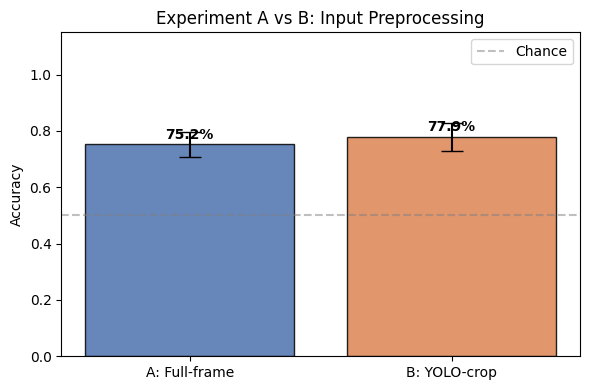

In [9]:
mean_A = np.mean(accs_A)
mean_B = np.mean(accs_B)

comparison_ab = pd.DataFrame({
    "Experiment": ["A: Full-frame", "B: YOLO-crop"],
    "Mean Accuracy": [f"{mean_A:.1%}", f"{mean_B:.1%}"],
    "Std": [f"{np.std(accs_A):.1%}", f"{np.std(accs_B):.1%}"],
    "Per-Fold": [str([f'{a:.1%}' for a in accs_A]), str([f'{a:.1%}' for a in accs_B])],
    "Time (s)": [f"{time_A:.0f}", f"{time_B:.0f}"],
})
print(comparison_ab.to_string(index=False))

if mean_B > mean_A:
    WINNER_INPUT = "crop"
    winner_factory = make_cropped_dataset
    winner_factory_aug = make_cropped_dataset_aug
    winner_reps = reps_with_kps
    winner_name = "B: YOLO-crop"
    winner_accs = accs_B
    winner_results = results_B
    winner_time = time_B
else:
    WINNER_INPUT = "full"
    winner_factory = make_full_frame_dataset
    winner_factory_aug = make_full_frame_dataset_aug
    winner_reps = rep_segments
    winner_name = "A: Full-frame"
    winner_accs = accs_A
    winner_results = results_A
    winner_time = time_A

print(f"\nWinner: {winner_name} ({np.mean(winner_accs):.1%})")
print(f"Proceeding with {WINNER_INPUT} input for unfreezing experiments.")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["A: Full-frame", "B: YOLO-crop"],
    [mean_A, mean_B],
    yerr=[np.std(accs_A), np.std(accs_B)],
    capsize=8, color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="black",
)
for bar, m in zip(bars, [mean_A, mean_B]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{m:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment A vs B: Input Preprocessing")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ab_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Unfreezing Experiment

Using the winning input preprocessing, compare:
- **Frozen**: Only FC head trainable (baseline — already done above)
- **Unfreeze 1 block**: layer4 + FC trainable
- **Unfreeze 2 blocks**: layer3 + layer4 + FC trainable

In [10]:
unfreeze_results = {}

# Already have frozen results from the winner
unfreeze_results["frozen"] = {
    "accs": winner_accs,
    "results": winner_results,
    "time": winner_time,
    "params": make_model_frozen().trainable_param_count(),
}

for n_blocks in [1, 2]:
    def make_model_unfrozen(n=n_blocks):
        m = PushUpR3D(freeze_backbone=True)
        m.unfreeze_last_n_blocks(n)
        return m

    n_params = make_model_unfrozen().trainable_param_count()
    label = f"unfreeze_{n_blocks}"
    print(f"\n{'='*60}")
    print(f"Unfreeze {n_blocks} block(s): {n_params:,} trainable params")
    print(f"{'='*60}")

    t0 = time.time()
    res = run_rep_kfold_cv(
        model_factory=make_model_unfrozen,
        dataset_factory=winner_factory,
        rep_segments=winner_reps,
        n_splits=N_SPLITS,
        n_epochs=30,
        batch_size=8,
        lr=1e-4,    # lower LR for fine-tuning unfrozen layers
        patience=10,
        device_str=DEVICE,
        random_state=RANDOM_STATE,
        train_dataset_factory=winner_factory_aug,
    )
    elapsed = time.time() - t0

    accs = [f["val_accuracy"] for f in res["fold_results"]]
    print(f"  Per-fold: {[f'{a:.1%}' for a in accs]}")
    print(f"  Mean: {np.mean(accs):.1%} +/- {np.std(accs):.1%}")
    print(f"  Time: {elapsed:.0f}s")

    unfreeze_results[label] = {
        "accs": accs,
        "results": res,
        "time": elapsed,
        "params": n_params,
    }

INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)



Unfreeze 1 block(s): 24,909,826 trainable params
  Fold 0 | Epoch 01/30 | train_loss=0.5396 | val_loss=0.4917 | val_acc=75.4% *
  Fold 0 | Epoch 02/30 | train_loss=0.2379 | val_loss=0.5473 | val_acc=75.4%
  Fold 0 | Epoch 03/30 | train_loss=0.1605 | val_loss=0.5554 | val_acc=81.2% *
  Fold 0 | Epoch 04/30 | train_loss=0.1047 | val_loss=0.5268 | val_acc=76.8%
  Fold 0 | Epoch 05/30 | train_loss=0.0559 | val_loss=0.6039 | val_acc=79.7%
  Fold 0 | Epoch 06/30 | train_loss=0.0755 | val_loss=0.6710 | val_acc=76.8%
  Fold 0 | Epoch 07/30 | train_loss=0.0439 | val_loss=0.5870 | val_acc=78.3%
  Fold 0 | Epoch 08/30 | train_loss=0.0570 | val_loss=0.5328 | val_acc=79.7%
  Fold 0 | Epoch 09/30 | train_loss=0.0682 | val_loss=0.6122 | val_acc=79.7%
  Fold 0 | Epoch 10/30 | train_loss=0.0646 | val_loss=0.8471 | val_acc=81.2%
  Fold 0 | Epoch 11/30 | train_loss=0.0342 | val_loss=0.8480 | val_acc=79.7%
  Fold 0 | Epoch 12/30 | train_loss=0.0377 | val_loss=0.6343 | val_acc=73.9%


INFO: Fold 0: early stopping at epoch 12 (best_acc=0.8116)


  Fold 0 | Epoch 13/30 | train_loss=0.0373 | val_loss=0.4939 | val_acc=79.7%


INFO: Fold 0: val_accuracy=0.8116
INFO: Fold 1: train=287 reps (190 vids), val=70 reps (48 vids)


...

  Fold 4 | Epoch 01/30 | train_loss=0.5433 | val_loss=0.6778 | val_acc=74.7% *
  Fold 4 | Epoch 02/30 | train_loss=0.2475 | val_loss=0.4603 | val_acc=82.7% *
  Fold 4 | Epoch 03/30 | train_loss=0.1428 | val_loss=0.5043 | val_acc=77.3%
  Fold 4 | Epoch 04/30 | train_loss=0.1068 | val_loss=0.6278 | val_acc=77.3%
  Fold 4 | Epoch 05/30 | train_loss=0.0958 | val_loss=0.6976 | val_acc=81.3%
  Fold 4 | Epoch 06/30 | train_loss=0.0666 | val_loss=0.6775 | val_acc=81.3%
  Fold 4 | Epoch 07/30 | train_loss=0.0526 | val_loss=0.6808 | val_acc=85.3% *
  Fold 4 | Epoch 08/30 | train_loss=0.1313 | val_loss=1.1531 | val_acc=81.3%
  Fold 4 | Epoch 09/30 | train_loss=0.1575 | val_loss=0.7839 | val_acc=81.3%
  Fold 4 | Epoch 10/30 | train_loss=0.0957 | val_loss=1.1181 | val_acc=82.7%
  Fold 4 | Epoch 11/30 | train_loss=0.1049 | val_loss=0.5017 | val_acc=88.0% *
  Fold 4 | Epoch 12/30 | train_loss=0.0428 | val_loss=0.4325 | val_acc=88.0%
  Fold 4 | Epoch 13/30 | train_loss=0.0300 | val_loss=0.6021 | val_a

INFO: Fold 4: early stopping at epoch 20 (best_acc=0.8800)


  Fold 4 | Epoch 21/30 | train_loss=0.1312 | val_loss=0.3200 | val_acc=88.0%


INFO: Fold 4: val_accuracy=0.8800


  Per-fold: ['89.9%', '85.7%', '94.1%', '92.0%', '88.0%']
  Mean: 89.9% +/- 2.9%
  Time: 470s


                      Config Trainable Params Mean Accuracy  Std Time (s)
            Frozen (FC only)            1,026         77.9% 4.9%      429
   Unfreeze 1 block (layer4)       24,909,826         86.8% 3.0%      347
Unfreeze 2 blocks (layer3+4)       31,138,306         89.9% 2.9%      470


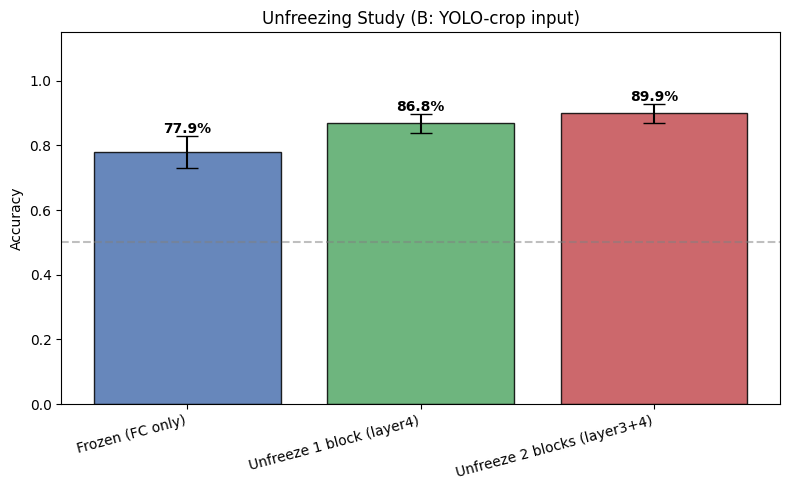


Best unfreezing config: unfreeze_2 (89.9%)


In [11]:
# Unfreezing comparison table
unfreeze_labels = ["frozen", "unfreeze_1", "unfreeze_2"]
display_names = ["Frozen (FC only)", "Unfreeze 1 block (layer4)", "Unfreeze 2 blocks (layer3+4)"]

unfreeze_df = pd.DataFrame({
    "Config": display_names,
    "Trainable Params": [f"{unfreeze_results[k]['params']:,}" for k in unfreeze_labels],
    "Mean Accuracy": [f"{np.mean(unfreeze_results[k]['accs']):.1%}" for k in unfreeze_labels],
    "Std": [f"{np.std(unfreeze_results[k]['accs']):.1%}" for k in unfreeze_labels],
    "Time (s)": [f"{unfreeze_results[k]['time']:.0f}" for k in unfreeze_labels],
})
print(unfreeze_df.to_string(index=False))

# Bar chart
means_u = [np.mean(unfreeze_results[k]["accs"]) for k in unfreeze_labels]
stds_u = [np.std(unfreeze_results[k]["accs"]) for k in unfreeze_labels]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(display_names, means_u, yerr=stds_u, capsize=8,
              color=colors, alpha=0.85, edgecolor="black")
for bar, m, s in zip(bars, means_u, stds_u):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f"{m:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_title(f"Unfreezing Study ({winner_name} input)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "unfreeze_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Pick best unfreezing config
best_unfreeze = max(unfreeze_labels, key=lambda k: np.mean(unfreeze_results[k]["accs"]))
best_unfreeze_acc = np.mean(unfreeze_results[best_unfreeze]["accs"])
print(f"\nBest unfreezing config: {best_unfreeze} ({best_unfreeze_acc:.1%})")

---
## Hyperparameter Tuning

Grid search over learning rate and batch size using the best config from above.

In [12]:
# Determine the best model factory based on unfreezing results
def _make_best_model():
    m = PushUpR3D(freeze_backbone=True)
    if best_unfreeze == "unfreeze_1":
        m.unfreeze_last_n_blocks(1)
    elif best_unfreeze == "unfreeze_2":
        m.unfreeze_last_n_blocks(2)
    return m

print(f"Tuning config: {best_unfreeze} + {WINNER_INPUT} input")
print(f"  Trainable params: {_make_best_model().trainable_param_count():,}")

# Hyperparameter grid
LR_OPTIONS = [1e-4, 5e-4, 1e-3]
BS_OPTIONS = [4, 8, 16]

hp_results = []

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        print(f"\n--- lr={lr}, batch_size={bs} ---")
        t0 = time.time()
        res = run_rep_kfold_cv(
            model_factory=_make_best_model,
            dataset_factory=winner_factory,
            rep_segments=winner_reps,
            n_splits=N_SPLITS,
            n_epochs=30,
            batch_size=bs,
            lr=lr,
            patience=10,
            device_str=DEVICE,
            random_state=RANDOM_STATE,
            train_dataset_factory=winner_factory_aug,
        )
        elapsed = time.time() - t0
        accs = [f["val_accuracy"] for f in res["fold_results"]]
        mean_acc = np.mean(accs)
        std_acc = np.std(accs)
        print(f"  Mean: {mean_acc:.1%} +/- {std_acc:.1%} ({elapsed:.0f}s)")

        hp_results.append({
            "lr": lr,
            "batch_size": bs,
            "mean_acc": mean_acc,
            "std_acc": std_acc,
            "per_fold": accs,
            "time": elapsed,
            "results": res,
        })

Tuning config: unfreeze_2 + crop input


INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)


  Trainable params: 31,138,306

--- lr=0.0001, batch_size=4 ---
  Fold 0 | Epoch 01/30 | train_loss=0.6078 | val_loss=0.5878 | val_acc=65.2% *
  Fold 0 | Epoch 02/30 | train_loss=0.3280 | val_loss=0.5049 | val_acc=76.8% *
  Fold 0 | Epoch 03/30 | train_loss=0.2521 | val_loss=0.5422 | val_acc=76.8%
  Fold 0 | Epoch 04/30 | train_loss=0.3129 | val_loss=0.7022 | val_acc=73.9%
  Fold 0 | Epoch 05/30 | train_loss=0.2023 | val_loss=0.5419 | val_acc=73.9%
  Fold 0 | Epoch 06/30 | train_loss=0.2027 | val_loss=0.5044 | val_acc=84.1% *
  Fold 0 | Epoch 07/30 | train_loss=0.1875 | val_loss=0.4993 | val_acc=81.2%
  Fold 0 | Epoch 08/30 | train_loss=0.2341 | val_loss=0.3761 | val_acc=84.1%
  Fold 0 | Epoch 09/30 | train_loss=0.1640 | val_loss=0.6370 | val_acc=76.8%
  Fold 0 | Epoch 10/30 | train_loss=0.1584 | val_loss=0.5807 | val_acc=73.9%
  Fold 0 | Epoch 11/30 | train_loss=0.1212 | val_loss=0.5841 | val_acc=73.9%
  Fold 0 | Epoch 12/30 | train_loss=0.1297 | val_loss=0.3251 | val_acc=78.3%
  Fold

INFO: Fold 0: early stopping at epoch 15 (best_acc=0.8406)


  Fold 0 | Epoch 16/30 | train_loss=0.1150 | val_loss=0.3831 | val_acc=79.7%


...

  Fold 4 | Epoch 01/30 | train_loss=0.6167 | val_loss=30.3409 | val_acc=57.3% *
  Fold 4 | Epoch 02/30 | train_loss=0.3598 | val_loss=1.9372 | val_acc=72.0% *
  Fold 4 | Epoch 03/30 | train_loss=0.2001 | val_loss=1.2732 | val_acc=73.3% *
  Fold 4 | Epoch 04/30 | train_loss=0.1406 | val_loss=0.4081 | val_acc=84.0% *
  Fold 4 | Epoch 05/30 | train_loss=0.0808 | val_loss=1.0133 | val_acc=80.0%
  Fold 4 | Epoch 06/30 | train_loss=0.1315 | val_loss=0.6323 | val_acc=82.7%
  Fold 4 | Epoch 07/30 | train_loss=0.1105 | val_loss=0.3273 | val_acc=93.3% *
  Fold 4 | Epoch 08/30 | train_loss=0.0620 | val_loss=0.5782 | val_acc=88.0%
  Fold 4 | Epoch 09/30 | train_loss=0.0915 | val_loss=0.6627 | val_acc=82.7%
  Fold 4 | Epoch 10/30 | train_loss=0.0606 | val_loss=0.6204 | val_acc=88.0%
  Fold 4 | Epoch 11/30 | train_loss=0.0439 | val_loss=0.7071 | val_acc=84.0%
  Fold 4 | Epoch 12/30 | train_loss=0.0335 | val_loss=1.0029 | val_acc=84.0%
  Fold 4 | Epoch 13/30 | train_loss=0.1138 | val_loss=0.5618 | va

INFO: Fold 4: early stopping at epoch 16 (best_acc=0.9333)


  Fold 4 | Epoch 17/30 | train_loss=0.0091 | val_loss=0.8314 | val_acc=81.3%


INFO: Fold 4: val_accuracy=0.9333


  Mean: 92.1% +/- 2.1% (452s)


   LR  Batch Size Mean Accuracy  Std Time (s)
1e-04           4         89.7% 4.1%      469
1e-04           8         91.1% 2.8%      590
1e-04          16         87.6% 4.1%      410
5e-04           4         93.0% 1.8%      557
5e-04           8         93.9% 2.6%      463
5e-04          16         90.5% 1.1%      414
1e-03           4         91.3% 2.6%      649
1e-03           8         90.8% 1.7%      421
1e-03          16         92.1% 2.1%      452


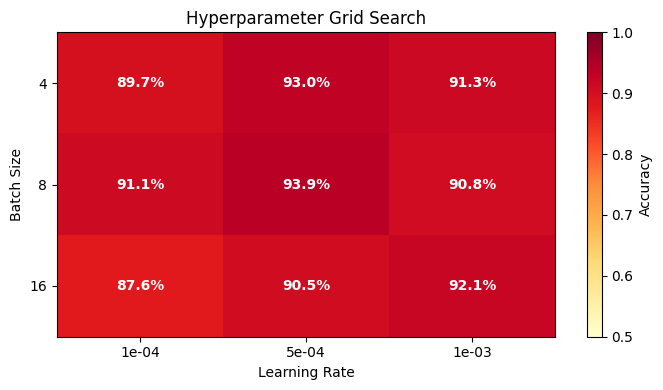


Best hyperparams: lr=5e-04, batch_size=8
  Accuracy: 93.9% +/- 2.6%


In [13]:
# Hyperparameter results table
hp_df = pd.DataFrame([
    {
        "LR": f"{r['lr']:.0e}",
        "Batch Size": r["batch_size"],
        "Mean Accuracy": f"{r['mean_acc']:.1%}",
        "Std": f"{r['std_acc']:.1%}",
        "Time (s)": f"{r['time']:.0f}",
    }
    for r in hp_results
])
print(hp_df.to_string(index=False))

# Heatmap
pivot = pd.DataFrame(hp_results).pivot(
    index="batch_size", columns="lr", values="mean_acc"
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.0e}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Batch Size")
ax.set_title("Hyperparameter Grid Search")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                fontweight="bold", color="white" if val > 0.75 else "black")

plt.colorbar(im, label="Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hp_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Best HP config
best_hp = max(hp_results, key=lambda r: r["mean_acc"])
print(f"\nBest hyperparams: lr={best_hp['lr']:.0e}, batch_size={best_hp['batch_size']}")
print(f"  Accuracy: {best_hp['mean_acc']:.1%} +/- {best_hp['std_acc']:.1%}")

---
## Final Comparison

Summary of all experiments in a single table and chart.

In [14]:
# Build final comparison
all_experiments = []

# A: full-frame frozen
all_experiments.append({
    "Experiment": "A: Full-frame (frozen)",
    "Input": "Full-frame",
    "Backbone": "Frozen",
    "Params": f"{make_model_frozen().trainable_param_count():,}",
    "LR": "1e-3",
    "Batch Size": 8,
    "Mean Acc": np.mean(accs_A),
    "Std": np.std(accs_A),
    "Time (s)": f"{time_A:.0f}",
})

# B: YOLO-crop frozen
all_experiments.append({
    "Experiment": "B: YOLO-crop (frozen)",
    "Input": "YOLO-crop",
    "Backbone": "Frozen",
    "Params": f"{make_model_frozen().trainable_param_count():,}",
    "LR": "1e-3",
    "Batch Size": 8,
    "Mean Acc": np.mean(accs_B),
    "Std": np.std(accs_B),
    "Time (s)": f"{time_B:.0f}",
})

# Unfreezing experiments
for label, display in [("unfreeze_1", "Unfreeze 1 block"), ("unfreeze_2", "Unfreeze 2 blocks")]:
    r = unfreeze_results[label]
    all_experiments.append({
        "Experiment": f"{display} ({WINNER_INPUT})",
        "Input": WINNER_INPUT.capitalize(),
        "Backbone": display,
        "Params": f"{r['params']:,}",
        "LR": "1e-4",
        "Batch Size": 8,
        "Mean Acc": np.mean(r["accs"]),
        "Std": np.std(r["accs"]),
        "Time (s)": f"{r['time']:.0f}",
    })

# Best HP
all_experiments.append({
    "Experiment": f"Best HP ({best_unfreeze}, {WINNER_INPUT})",
    "Input": WINNER_INPUT.capitalize(),
    "Backbone": best_unfreeze.replace("_", " ").title(),
    "Params": f"{_make_best_model().trainable_param_count():,}",
    "LR": f"{best_hp['lr']:.0e}",
    "Batch Size": best_hp["batch_size"],
    "Mean Acc": best_hp["mean_acc"],
    "Std": best_hp["std_acc"],
    "Time (s)": f"{best_hp['time']:.0f}",
})

final_df = pd.DataFrame(all_experiments)
print(final_df.to_string(index=False))

                Experiment      Input          Backbone     Params    LR  Batch Size  Mean Acc      Std Time (s)
    A: Full-frame (frozen) Full-frame            Frozen      1,026  1e-3           8  0.752026 0.044882      472
     B: YOLO-crop (frozen)  YOLO-crop            Frozen      1,026  1e-3           8  0.778563 0.049347      429
   Unfreeze 1 block (crop)       Crop  Unfreeze 1 block 24,909,826  1e-4           8  0.868207 0.029951      347
  Unfreeze 2 blocks (crop)       Crop Unfreeze 2 blocks 31,138,306  1e-4           8  0.899374 0.029436      470
Best HP (unfreeze_2, crop)       Crop        Unfreeze 2 31,138,306 5e-04           8  0.938568 0.025789      463


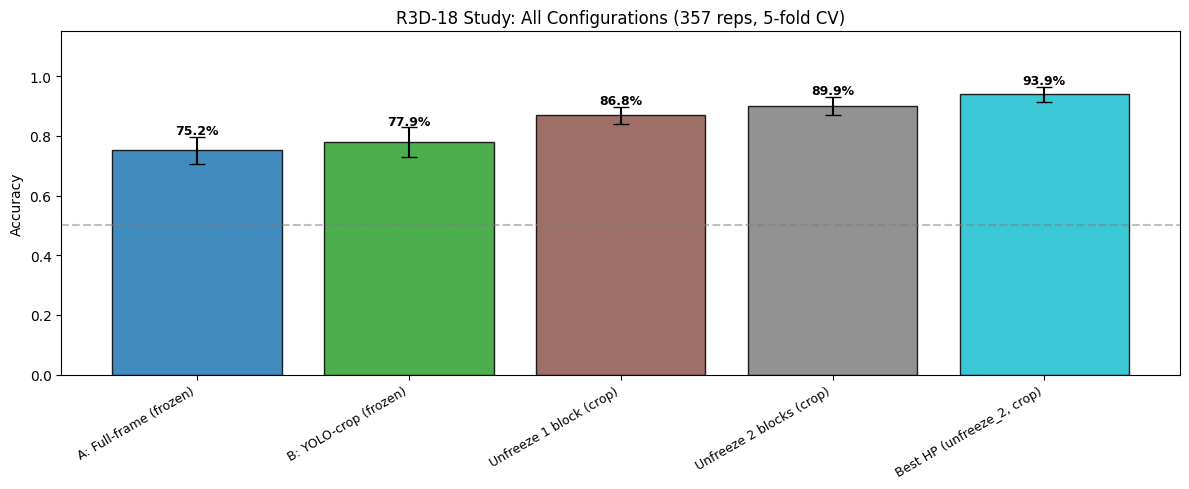


Best overall: Best HP (unfreeze_2, crop)
  Accuracy: 93.9% +/- 2.6%
  Config: 31,138,306 params, lr=5e-04, bs=8


In [15]:
# Final bar chart
names = final_df["Experiment"].tolist()
means_f = final_df["Mean Acc"].tolist()
stds_f = final_df["Std"].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
bars = ax.bar(range(len(names)), means_f, yerr=stds_f, capsize=6,
              color=colors, alpha=0.85, edgecolor="black")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)

for bar, m, s in zip(bars, means_f, stds_f):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f"{m:.1%}", ha="center", fontweight="bold", fontsize=9)

ax.set_ylabel("Accuracy")
ax.set_title(f"R3D-18 Study: All Configurations ({len(rep_segments)} reps, {N_SPLITS}-fold CV)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight best
best_row = final_df.loc[final_df["Mean Acc"].idxmax()]
print(f"\nBest overall: {best_row['Experiment']}")
print(f"  Accuracy: {best_row['Mean Acc']:.1%} +/- {best_row['Std']:.1%}")
print(f"  Config: {best_row['Params']} params, lr={best_row['LR']}, bs={best_row['Batch Size']}")

---
## Overfitting Analysis

Three checks:
1. **Train vs val loss curves** — diverging curves = overfitting
2. **Confusion matrix** — is the model biased toward one class?
3. **Per-video error analysis** — are errors spread across videos or concentrated?

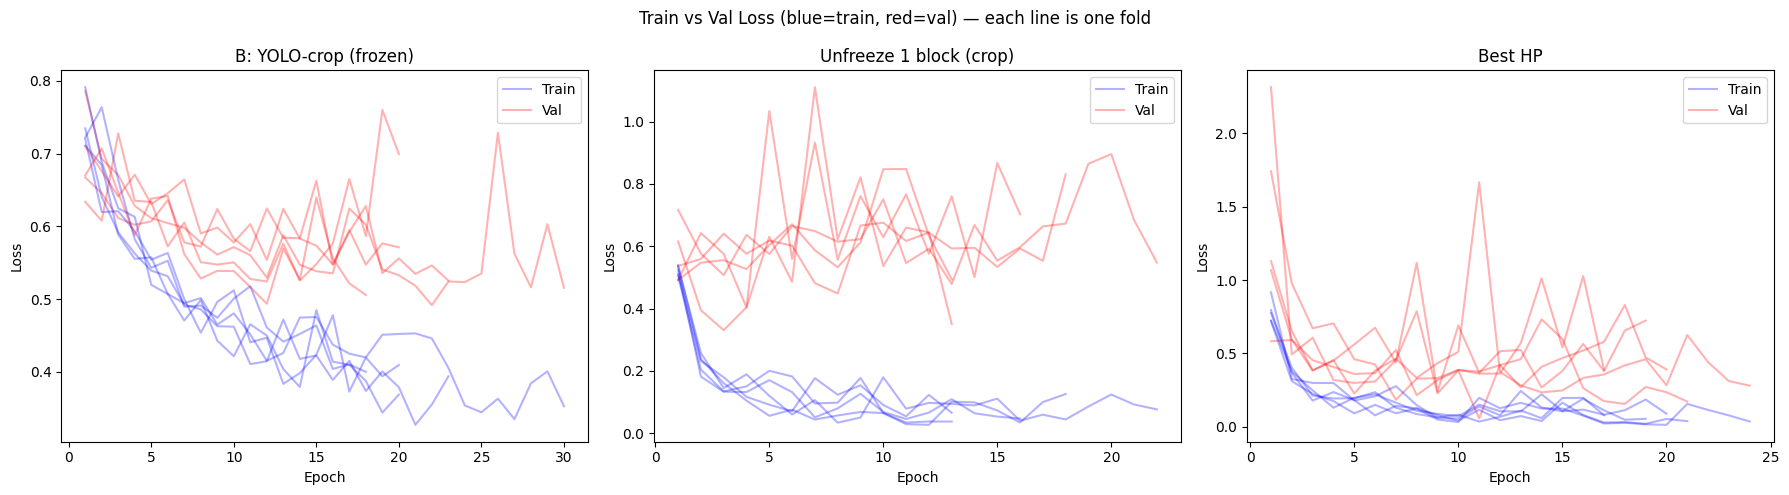

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

# ---- 1. Train vs Val Loss Curves ----
# Compare frozen (B) vs best unfrozen to see overfitting gap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_to_plot = [
    ("B: YOLO-crop (frozen)", results_B),
    (f"Unfreeze 1 block (crop)", unfreeze_results["unfreeze_1"]["results"]),
    (f"Best HP", best_hp["results"]),
]

for ax, (name, res) in zip(axes, configs_to_plot):
    for fold_res in res["fold_results"]:
        if "epoch_train_losses" not in fold_res:
            ax.set_title(f"{name}\n(no epoch history — rerun needed)")
            continue
        epochs = range(1, len(fold_res["epoch_train_losses"]) + 1)
        ax.plot(epochs, fold_res["epoch_train_losses"], "b-", alpha=0.3)
        ax.plot(epochs, fold_res["epoch_val_losses"], "r-", alpha=0.3)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{name}")
    ax.legend(["Train", "Val"], loc="upper right")

plt.suptitle("Train vs Val Loss (blue=train, red=val) — each line is one fold", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overfitting_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

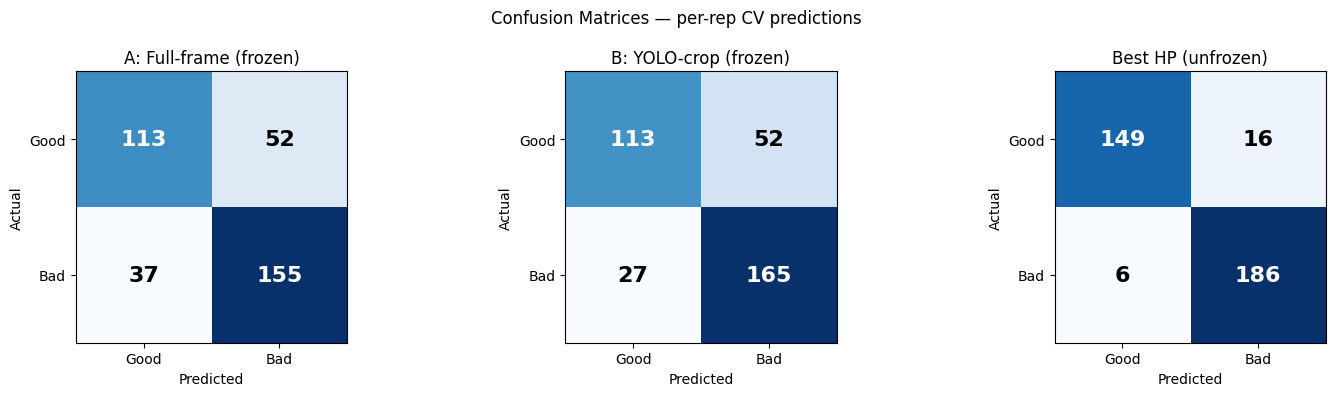


A: Full-frame (frozen):
              precision    recall  f1-score   support

        Good       0.75      0.68      0.72       165
         Bad       0.75      0.81      0.78       192

    accuracy                           0.75       357
   macro avg       0.75      0.75      0.75       357
weighted avg       0.75      0.75      0.75       357


B: YOLO-crop (frozen):
              precision    recall  f1-score   support

        Good       0.81      0.68      0.74       165
         Bad       0.76      0.86      0.81       192

    accuracy                           0.78       357
   macro avg       0.78      0.77      0.77       357
weighted avg       0.78      0.78      0.78       357


Best HP (unfrozen):
              precision    recall  f1-score   support

        Good       0.96      0.90      0.93       165
         Bad       0.92      0.97      0.94       192

    accuracy                           0.94       357
   macro avg       0.94      0.94      0.94       357
weig

In [17]:
# ---- 2. Confusion Matrices ----
# Compare frozen vs best unfrozen predictions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs_cm = [
    ("A: Full-frame (frozen)", results_A),
    ("B: YOLO-crop (frozen)", results_B),
    ("Best HP (unfrozen)", best_hp["results"]),
]

for ax, (name, res) in zip(axes, configs_cm):
    preds = res["per_rep_preds"]
    true = res["per_rep_true"]
    # Filter out None predictions (shouldn't happen but just in case)
    valid = [(p, t) for p, t in zip(preds, true) if p is not None]
    if not valid:
        continue
    p, t = zip(*valid)
    cm = confusion_matrix(t, p, labels=[0, 1])

    im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Good", "Bad"])
    ax.set_yticklabels(["Good", "Bad"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle("Confusion Matrices — per-rep CV predictions", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Print classification reports
for name, res in configs_cm:
    preds = [p for p in res["per_rep_preds"] if p is not None]
    true = [t for p, t in zip(res["per_rep_preds"], res["per_rep_true"]) if p is not None]
    print(f"\n{name}:")
    print(classification_report(true, preds, target_names=["Good", "Bad"]))

In [ ]:
# ---- 3. Per-Video Error Analysis (Best HP model) ----
best_preds = best_hp["results"]["per_rep_preds"]
best_true = best_hp["results"]["per_rep_true"]
best_confs = best_hp["results"].get("per_rep_confs", [None] * len(best_preds))

# Use the reps that match the winner (crop = reps_with_kps, full = rep_segments)
analysis_reps = winner_reps

video_stats = {}
for i, rep in enumerate(analysis_reps):
    vid = rep["video_id"]
    pred = best_preds[i]
    true = best_true[i]
    conf = best_confs[i] if best_confs[i] is not None else 0.0
    if pred is None:
        continue
    if vid not in video_stats:
        video_stats[vid] = {"correct": 0, "wrong": 0, "label": rep["label"],
                            "wrong_confs": [], "reps": []}
    is_correct = pred == true
    if is_correct:
        video_stats[vid]["correct"] += 1
    else:
        video_stats[vid]["wrong"] += 1
        video_stats[vid]["wrong_confs"].append(conf)
    video_stats[vid]["reps"].append({
        "rep_idx": rep.get("rep_idx", i),
        "pred": pred, "true": true, "conf": conf, "correct": is_correct,
    })

error_videos = {k: v for k, v in video_stats.items() if v["wrong"] > 0}
perfect_videos = {k: v for k, v in video_stats.items() if v["wrong"] == 0}

print(f"Total videos: {len(video_stats)}")
print(f"Perfect (0 errors): {len(perfect_videos)}")
print(f"With errors: {len(error_videos)}")

if error_videos:
    print(f"\n{'Video':<35} {'Label':<8} {'Correct':<10} {'Wrong':<8} {'Avg Conf':<10}")
    print("-" * 75)
    for vid, stats in sorted(error_videos.items(), key=lambda x: -x[1]["wrong"]):
        label = "Good" if stats["label"] == 0 else "Bad"
        avg_conf = np.mean(stats["wrong_confs"]) if stats["wrong_confs"] else 0
        print(f"{vid:<35} {label:<8} {stats['correct']:<10} {stats['wrong']:<8} {avg_conf:<10.1%}")

        # Show individual misclassified reps
        for r in stats["reps"]:
            if not r["correct"]:
                pred_str = "GOOD" if r["pred"] == 0 else "BAD"
                true_str = "GOOD" if r["true"] == 0 else "BAD"
                print(f"  -> Rep {r['rep_idx']}: predicted {pred_str} ({r['conf']:.1%}), actual {true_str}")

good_errors = sum(v["wrong"] for v in error_videos.values() if v["label"] == 0)
bad_errors = sum(v["wrong"] for v in error_videos.values() if v["label"] == 1)
print(f"\nMisclassified reps from 'good' videos: {good_errors}")
print(f"Misclassified reps from 'bad' videos: {bad_errors}")

# ---- Visualizations ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Error distribution histogram
error_counts = [v["wrong"] for v in video_stats.values()]
axes[0].hist(error_counts, bins=range(max(error_counts) + 2), edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Misclassified reps per video")
axes[0].set_ylabel("Number of videos")
axes[0].set_title("Error Distribution")

# (b) Confidence distribution: correct vs wrong
correct_confs = []
wrong_confs = []
for i, rep in enumerate(analysis_reps):
    pred = best_preds[i]
    true = best_true[i]
    conf = best_confs[i]
    if pred is None or conf is None:
        continue
    if pred == true:
        correct_confs.append(conf)
    else:
        wrong_confs.append(conf)

axes[1].hist(correct_confs, bins=20, alpha=0.6, label=f"Correct ({len(correct_confs)})", color="green", edgecolor="black")
axes[1].hist(wrong_confs, bins=20, alpha=0.6, label=f"Wrong ({len(wrong_confs)})", color="red", edgecolor="black")
axes[1].set_xlabel("Prediction confidence")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence: Correct vs Wrong")
axes[1].legend()

# (c) Top error videos bar chart
if error_videos:
    top_errors = sorted(error_videos.items(), key=lambda x: -x[1]["wrong"])[:15]
    vids = [v[:20] + "..." if len(v) > 20 else v for v, _ in top_errors]
    wrongs = [s["wrong"] for _, s in top_errors]
    colors = ["#e74c3c" if s["label"] == 1 else "#2ecc71" for _, s in top_errors]
    axes[2].barh(range(len(vids)), wrongs, color=colors, edgecolor="black")
    axes[2].set_yticks(range(len(vids)))
    axes[2].set_yticklabels(vids, fontsize=8)
    axes[2].set_xlabel("Misclassified reps")
    axes[2].set_title("Most Error-Prone Videos")
    axes[2].invert_yaxis()
    from matplotlib.patches import Patch
    axes[2].legend(handles=[Patch(color="#2ecc71", label="Good video"),
                            Patch(color="#e74c3c", label="Bad video")], loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Summary ----
print(f"\n{'='*60}")
print(f"  Error Analysis Summary")
print(f"{'='*60}")
total_reps = sum(v["correct"] + v["wrong"] for v in video_stats.values())
total_wrong = sum(v["wrong"] for v in video_stats.values())
print(f"  Total reps evaluated: {total_reps}")
print(f"  Total misclassified: {total_wrong} ({total_wrong/total_reps:.1%})")
print(f"  Videos with errors: {len(error_videos)}/{len(video_stats)} ({len(error_videos)/len(video_stats):.1%})")
if wrong_confs:
    print(f"  Avg confidence on wrong predictions: {np.mean(wrong_confs):.1%}")
    print(f"  Avg confidence on correct predictions: {np.mean(correct_confs):.1%}")

---
## Save Results

In [19]:
# Save summary CSV
final_df.to_csv(OUTPUT_DIR / "r3d_study_results.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'r3d_study_results.csv'}")

# Save HP grid CSV
hp_df.to_csv(OUTPUT_DIR / "r3d_hp_grid.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'r3d_hp_grid.csv'}")

# Save best model weights + config for inference
if best_hp["results"]["best_state"] is not None:
    torch.save({
        "state_dict": best_hp["results"]["best_state"],
        "input_type": WINNER_INPUT,          # "crop" or "full"
        "unfreeze": best_unfreeze,           # "frozen", "unfreeze_1", "unfreeze_2"
        "n_frames": N_FRAMES,
        "accuracy": best_hp["mean_acc"],
        "lr": best_hp["lr"],
        "batch_size": best_hp["batch_size"],
    }, OUTPUT_DIR / "r3d_best.pt")
    print(f"Saved: {OUTPUT_DIR / 'r3d_best.pt'}")

print(f"\nAll outputs saved to: {OUTPUT_DIR.resolve()}")
print("\nFigures:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  {f.name}")
print("CSVs:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {f.name}")

Saved: outputs/r3d_study_results.csv
Saved: outputs/r3d_hp_grid.csv
Saved: outputs/r3d_best.pt

All outputs saved to: /workspace/pushup-tracker/r3d_study/outputs

Figures:
  ab_comparison.png
  confusion_matrices.png
  error_distribution.png
  final_comparison.png
  hp_heatmap.png
  overfitting_loss_curves.png
  unfreeze_comparison.png
CSVs:
  r3d_hp_grid.csv
  r3d_study_results.csv


---
## Inference Pipelines

Two modes for counting good push-up reps:

1. **Automatic** (`infer_automatic`): State machine auto-detects reps from pre-recorded video. No annotation needed.
2. **Record & Classify** (`live_record_and_classify`): Webcam record, then offline YOLO + state machine + R3D. Run via `python live_demo.py`.

Both pipelines: **YOLO keypoints → State machine → R3D classification → good rep count**

In [ ]:
from inference import load_model, infer_automatic, summarize, print_results

# Load the best saved model
device = DEVICE if torch.cuda.is_available() else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu"
model, config = load_model("outputs/r3d_best.pt", device=device)
print(f"Using device: {device}")
print(f"Input type: {config.get('input_type')}")
print(f"Unfreeze: {config.get('unfreeze')}")
print(f"CV accuracy: {config.get('accuracy', 0):.1%}")

In [ ]:
# ============================================================
# Automatic rep detection (no annotation needed)
# ============================================================
# Pipeline: YOLO → State Machine → R3D
# Just point to a video file — reps are detected automatically.
#
# Adjust thresholds if the state machine misses reps:
#   down_threshold: elbow angle (degrees) for "down" position (default 90)
#   up_threshold: elbow angle (degrees) for "up" position (default 160)

auto_test_videos = [
    # "videos/my_test_video.mp4",
    # "videos/another_video.mp4",
]

if not auto_test_videos:
    print("No test videos defined.")
    print("Add video paths to auto_test_videos above, then re-run this cell.")
else:
    all_auto_results = []

    for video_path in auto_test_videos:
        results_auto = infer_automatic(
            video_path=video_path,
            model=model,
            config=config,
            keypoint_dir=KEYPOINT_DIR,
            device=device,
            down_threshold=90.0,
            up_threshold=160.0,
            min_rep_frames=10,
        )
        print_results(results_auto, f"Automatic — {Path(video_path).name}")

        s = summarize(results_auto)
        print(f"\n  GOOD reps counted: {s['good_reps']} / {s['total_reps']}")

        all_auto_results.extend(results_auto)

    # Overall summary across all videos
    if len(auto_test_videos) > 1:
        s_all = summarize(all_auto_results)
        print(f"\n{'='*60}")
        print(f"  OVERALL: {s_all['good_reps']} GOOD / {s_all['total_reps']} total reps")
        print(f"{'='*60}")

In [ ]:
# ============================================================
# Live webcam: Record & Classify
# ============================================================
# Records webcam video, then processes offline for accurate classification.
# Press S to start/stop recording, Q/ESC to quit.
#
# NOTE: Run from terminal instead (cv2.imshow doesn't work in Jupyter):
#   cd r3d_study
#   python live_demo.py
#   python live_demo.py --camera 1       # external webcam
#   python live_demo.py --no-skeleton    # hide skeleton overlay

print("Live webcam demo must be run from terminal:")
print("  cd r3d_study")
print("  python live_demo.py")
print()
print("Controls: S = start/stop recording, Q/ESC = quit")

### Inference Pipeline Summary

| | Automatic (`infer_automatic`) | Record & Classify (`live_demo.py`) |
|---|---|---|
| **Rep boundaries** | State machine | State machine (offline) |
| **Pipeline** | YOLO → State Machine → R3D | Webcam → record → YOLO → State Machine → R3D |
| **Input** | Pre-recorded video file | Live webcam recording |
| **Use case** | Batch processing | Real-time demo |
| **Effort** | Zero — just provide video path | Zero — just press S to record |

- **Automatic** is for batch processing recorded videos end-to-end.
- **Record & Classify** is the live demo — record a set of reps, then get per-rep feedback.